In [2]:
import sys
sys.path.append('../funciones')
from barras_verticales import barras_verticales

import pandas as pd
import numpy as np

## Creación de los dataframes

In [3]:
df_desde_excel = pd.read_excel('conteos_por_dependencia_20062025_activos - copia.xlsx')
df_desde_excel

,anio,activos,desaparecidos_anuales,localizados_acumulados,localizados_anuales,nas_localizacion,indicadora_dependencia,datos,indicadora
0,2006,2637,641,27,95,0,TODOS,TODOS,1
1,2007,3183,3038,122,1602,0,TODOS,TODOS,1
2,2008,4619,3297,1724,1614,0,TODOS,TODOS,1
3,2009,6302,4903,3338,2211,0,TODOS,TODOS,1
4,2010,8994,7721,5549,1976,0,TODOS,TODOS,1
...,...,...,...,...,...,...,...,...,...
135,2021,104722,19211,75887,8141,0,TODOS,Pendientes,7
136,2022,115792,19653,84028,7686,0,TODOS,Pendientes,7
137,2023,127759,16218,91714,11869,0,TODOS,Pendientes,7
138,2024,132108,10935,103583,6341,0,TODOS,Pendientes,7


In [4]:
# Primero, obtenemos los valores únicos de la columna "indicadora"
indicadores_unicos = df_desde_excel['indicadora'].unique()

print(f"Se crearán {len(indicadores_unicos)} DataFrames a partir de los valores en la columna 'indicadora'.")

# Creamos un diccionario para almacenar los nuevos DataFrames.
# Esto permite acceder a ellos de forma programática.
dataframes_filtrados = {}

# Iteramos sobre los indicadores únicos y creamos un DataFrame para cada uno.
for indicador in indicadores_unicos:
    # Filtramos el DataFrame original.
    df_filtrado = df_desde_excel[df_desde_excel['indicadora'] == indicador].copy()
    
    # Definimos el mapeo para renombrar las columnas
    nuevos_nombres = {
        'anio': 'Año',
        'desaparecidos_anuales': 'Desaparecidos del periodo',
        'activos': 'Acumulado anterior',
        'localizados_anuales': 'Localizados del periodo',
        'localizados_acumulados': 'Localizados de años anteriores',
        #'Sin año de localización': 'Sin año de localización'
    }
    
    # Renombramos las columnas del DataFrame filtrado
    df_filtrado.rename(columns=nuevos_nombres, inplace=True)

    # Eliminamos las columnas no deseadas
    columnas_a_eliminar = ["activos", "indicadora_dependencia", "datos", "indicadora"]
    df_filtrado.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

    # Definimos el orden deseado de las columnas
    orden_columnas = [
        'Año', 
        'Acumulado anterior', 
        'Desaparecidos del periodo', 
        'Localizados de años anteriores', 
        'Localizados del periodo',
        #'Sin año de localización'
    ]
    
    # Reordenamos las columnas
    df_filtrado = df_filtrado[orden_columnas]

    # Convertir a negativo las columnas de localizados
    df_filtrado['Localizados de años anteriores'] = df_filtrado['Localizados de años anteriores'] * -1
    df_filtrado['Localizados del periodo'] = df_filtrado['Localizados del periodo'] * -1

    # Aseguramos que la columna 'Año' tenga formato de fecha
    # Usamos errors='coerce' para convertir los no-fechas a NaT (Not a Time)
    # df_filtrado['Año'] = pd.to_datetime(df_filtrado['Año'], format='%Y', errors='coerce')
    
    # Añadimos la nueva columna con ceros
    df_filtrado['Sin año de localización'] = 0
    
    # Guardamos el nuevo DataFrame en el diccionario.
    dataframes_filtrados[indicador] = df_filtrado
    print(f"- DataFrame para el indicador '{indicador}' creado, columnas procesadas y fila vacía añadida.")

# Para acceder a un DataFrame específico, puedes usar su nombre de indicador como clave.
# Ejemplo para ver el primer DataFrame creado:
if dataframes_filtrados:
    primer_indicador = list(dataframes_filtrados.keys())[0]
    print(f"\nMostrando el DataFrame para: '{primer_indicador}'")
    display(dataframes_filtrados[primer_indicador])

Se crearán 7 DataFrames a partir de los valores en la columna 'indicadora'.
- DataFrame para el indicador '1' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '2' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '3' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '4' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '5' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '6' creado, columnas procesadas y fila vacía añadida.
- DataFrame para el indicador '7' creado, columnas procesadas y fila vacía añadida.

Mostrando el DataFrame para: '1'


,Año,Acumulado anterior,Desaparecidos del periodo,Localizados de años anteriores,Localizados del periodo,Sin año de localización
0,2006,2637,641,-27,-95,0
1,2007,3183,3038,-122,-1602,0
2,2008,4619,3297,-1724,-1614,0
3,2009,6302,4903,-3338,-2211,0
4,2010,8994,7721,-5549,-1976,0
5,2011,14739,11366,-7525,-3657,0
6,2012,22448,11284,-11182,-4755,0
7,2013,28977,18283,-15937,-10527,0
8,2014,36733,18578,-26464,-10153,0
9,2015,45158,15396,-36617,-7290,0


## Gráficas

Scour processed file "output/dataframe_1.svg" in 197 ms: 62153/101814 bytes new/orig -> 61.0%


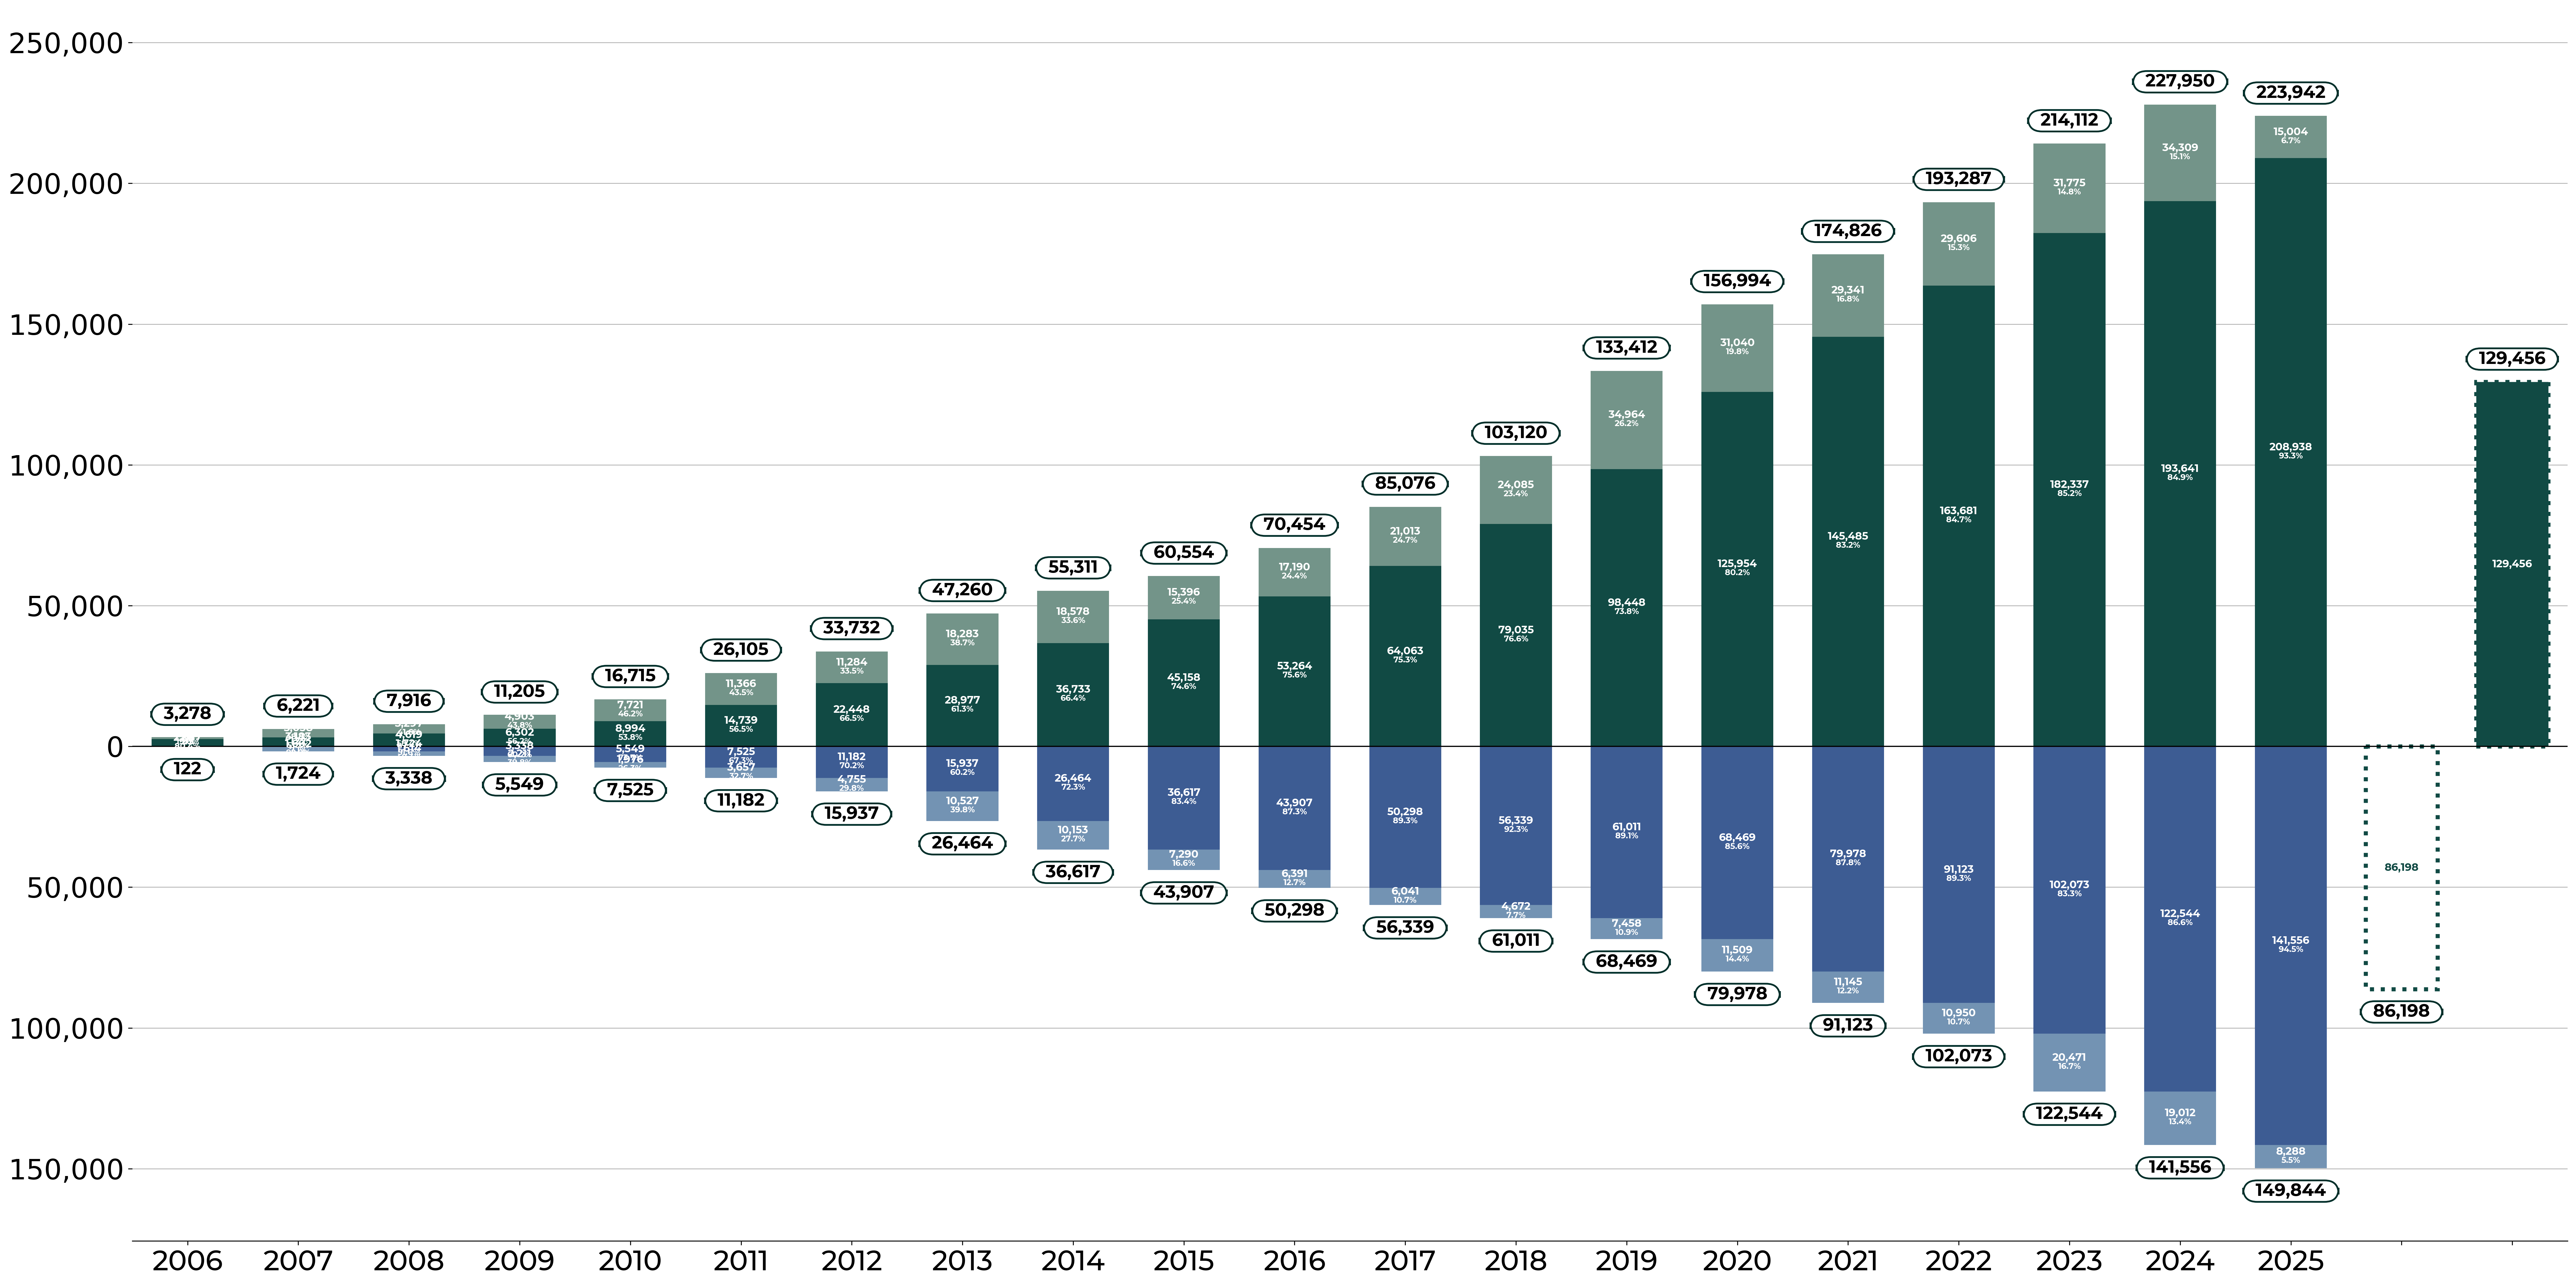

In [17]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[0]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[0]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       tam_letra_ejeX=24,
       tam_letra_ejeY=24,
       color_valor_barra='white',
       color_porce_barra='white',
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-86198), [None, None, None, None, "86,198"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,129456), [None, None, None, None, "129,456"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.33,
       div_ejeY=50000,
       )

Scour processed file "output/dataframe_2.svg" in 127 ms: 59343/98396 bytes new/orig -> 60.3%


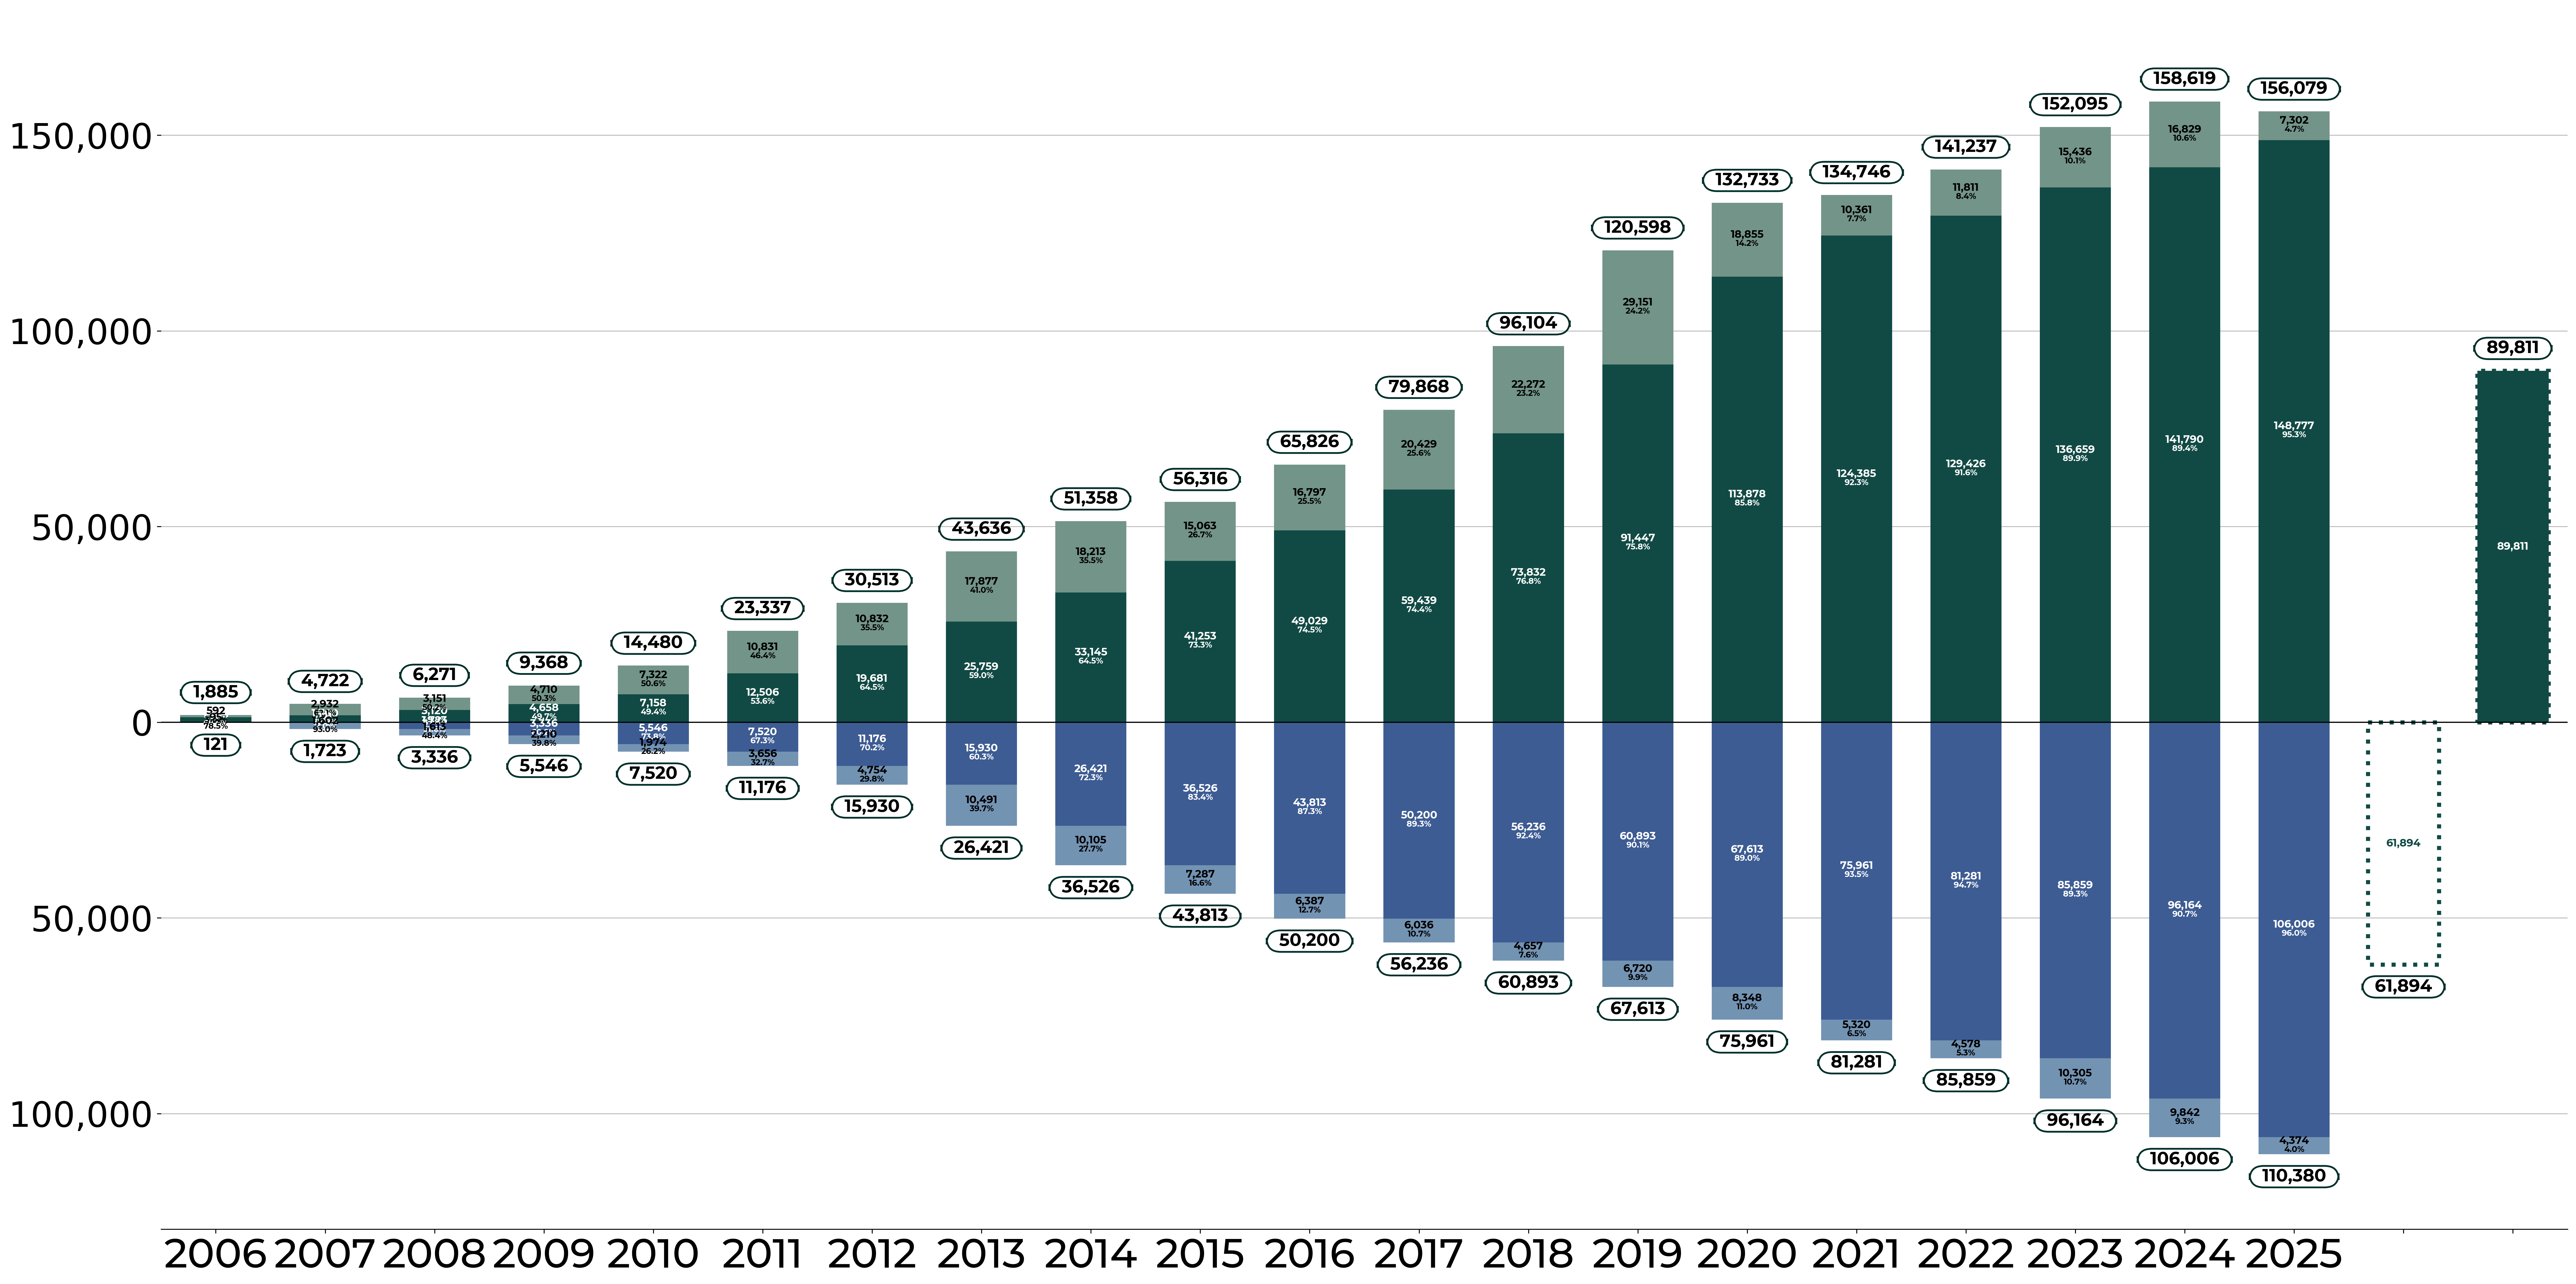

In [6]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[1]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[1]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-61894), [None, None, None, None, "61,894"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,89811), [None, None, None, None, "89,811"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.29,
       div_ejeY=50000,
       )

Scour processed file "output/dataframe_3.svg" in 69 ms: 34066/56729 bytes new/orig -> 60.1%


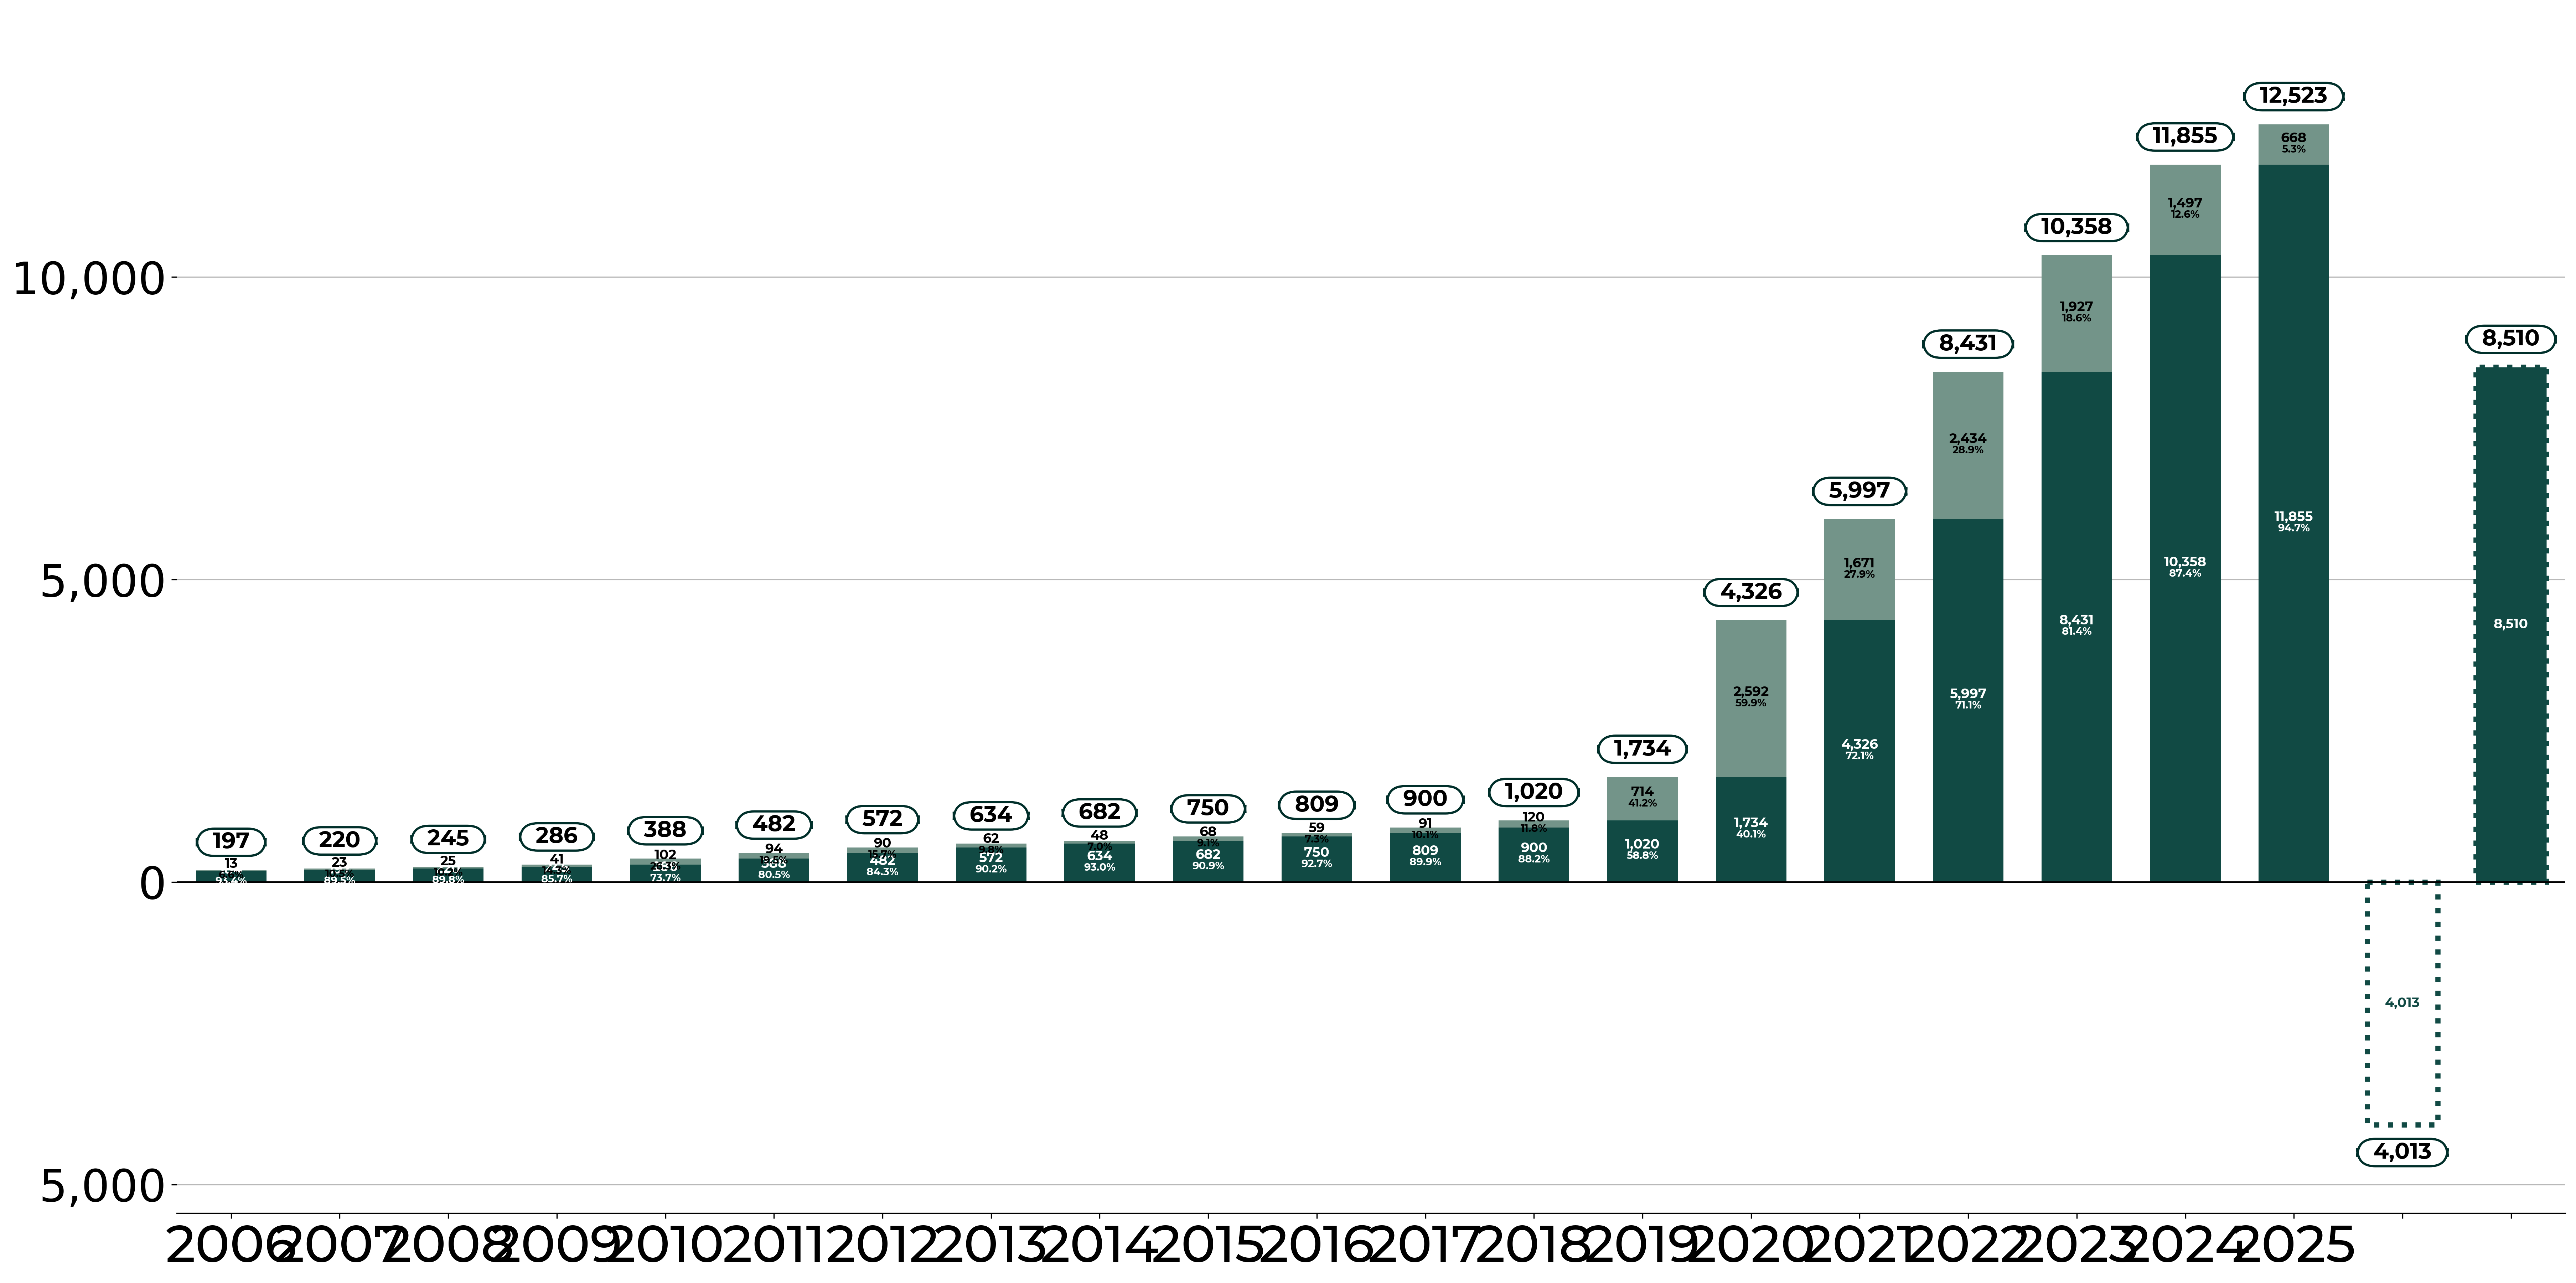

In [7]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[2]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[2]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-4013), [None, None, None, None, "4,013"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,8510), [None, None, None, None, "8,510"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.62,
       div_ejeY=False,
       )

Scour processed file "output/dataframe_4.svg" in 154 ms: 49470/82953 bytes new/orig -> 59.6%


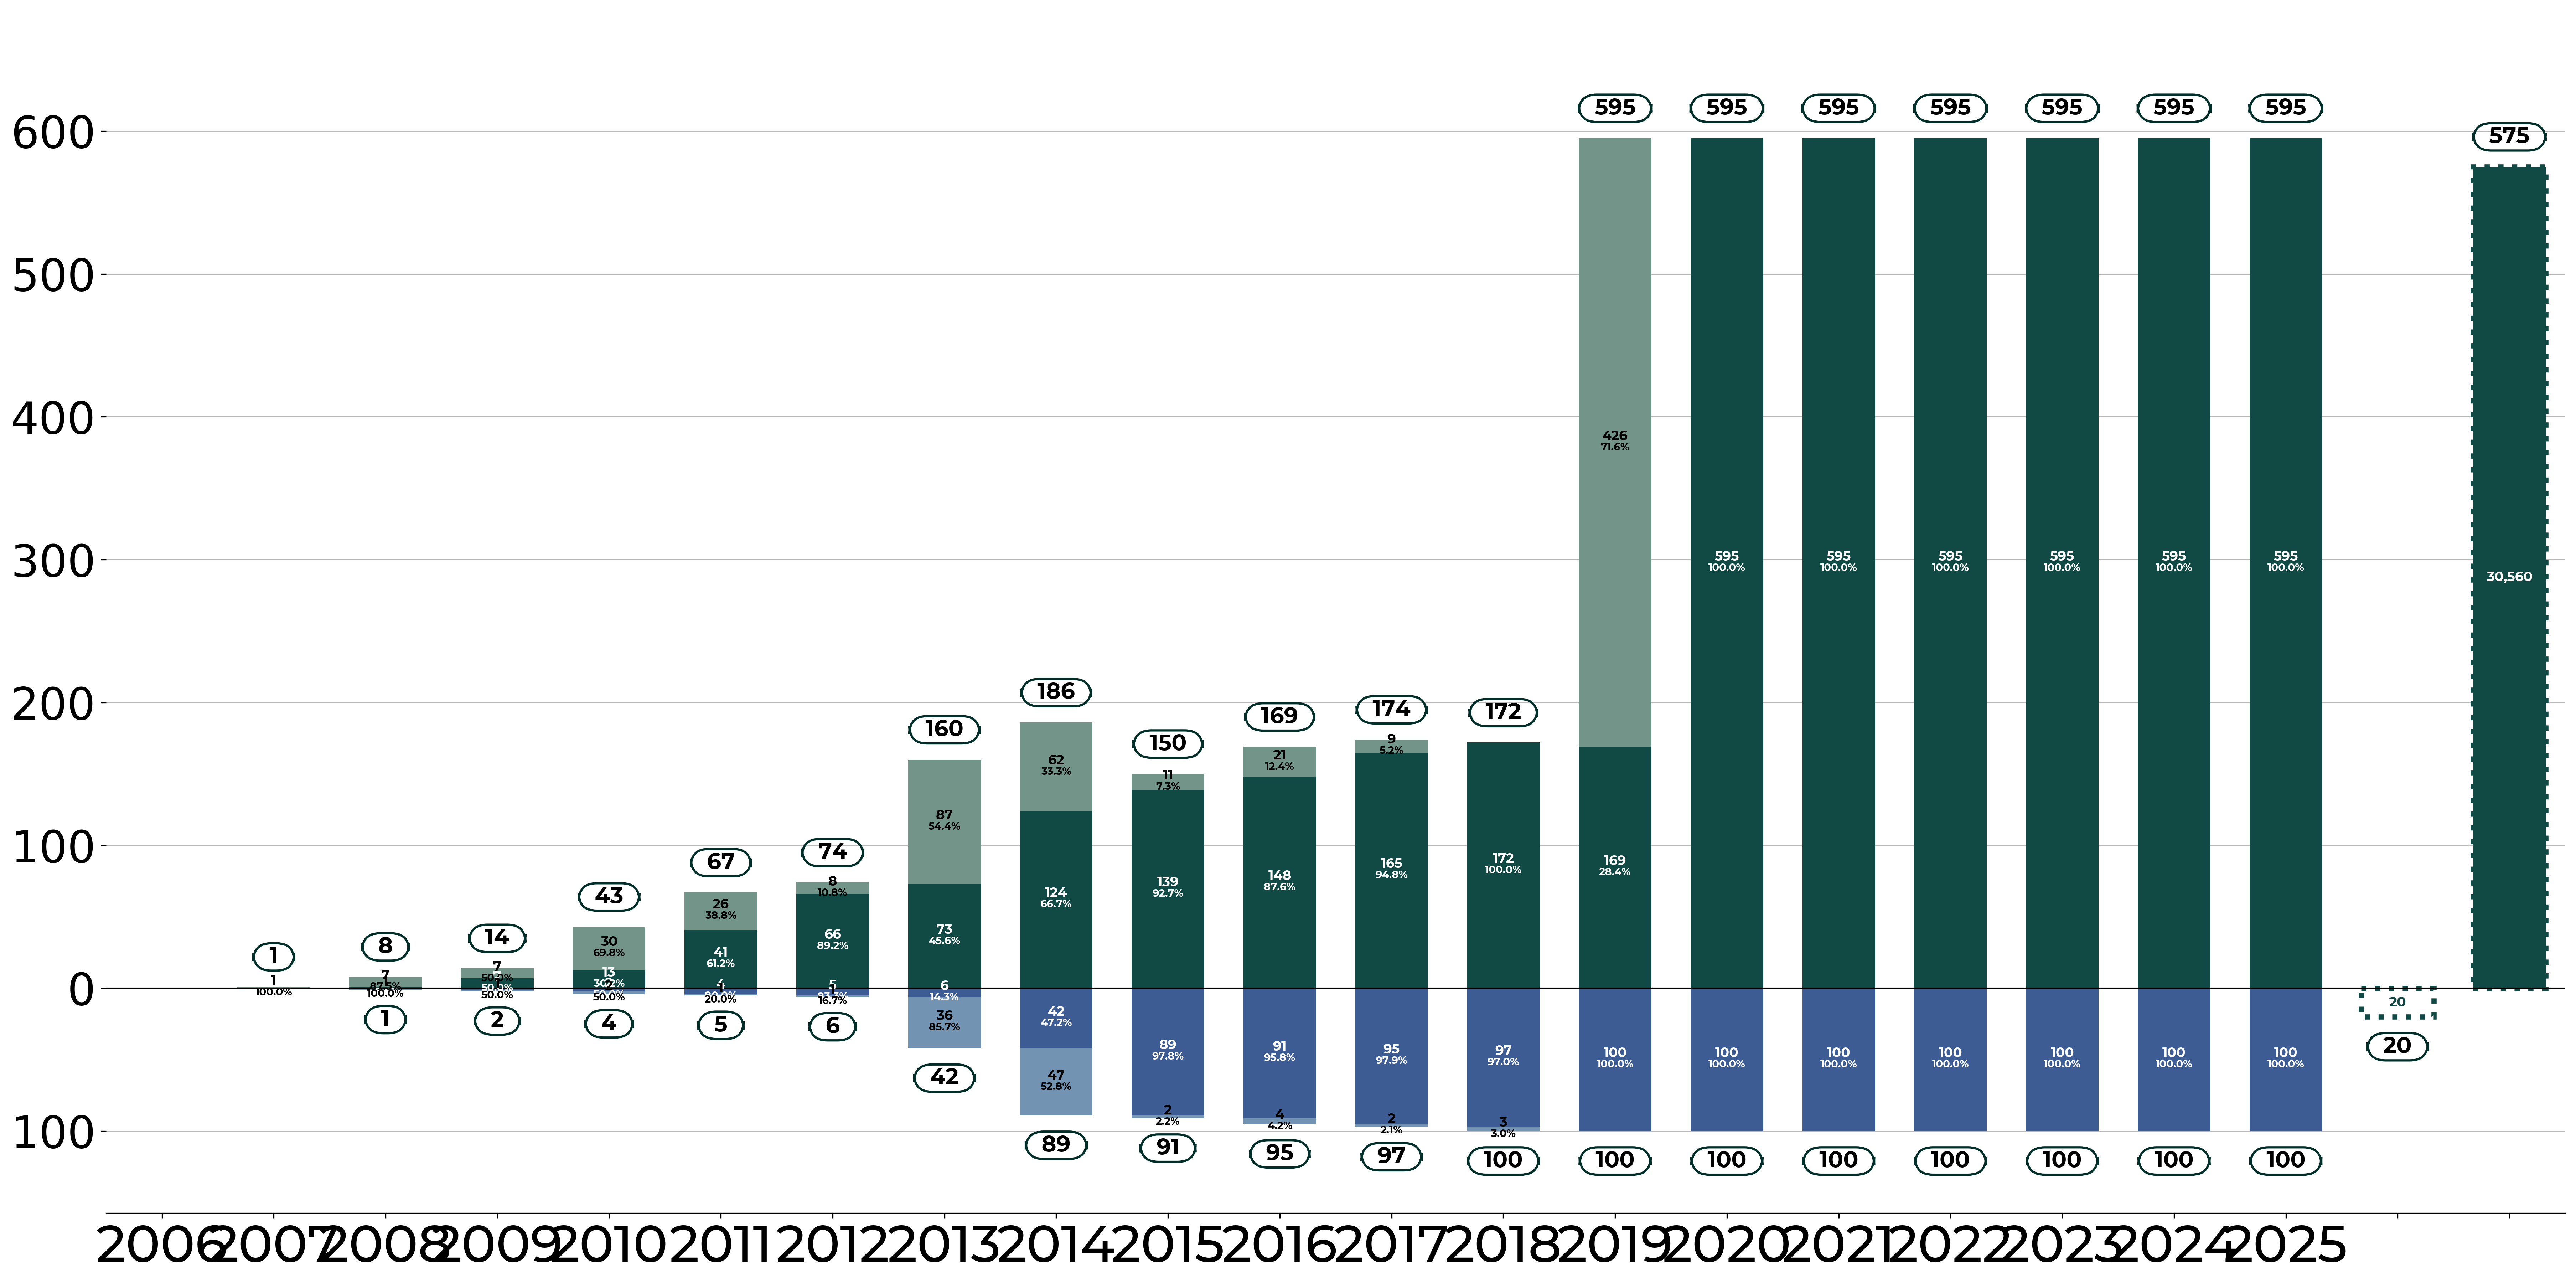

In [8]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[3]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[3]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-20), [None, None, None, None, "20"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,575), [None, None, None, None, "30,560"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.77,
       div_ejeY=False,
       )

Scour processed file "output/dataframe_5.svg" in 171 ms: 55421/92672 bytes new/orig -> 59.8%


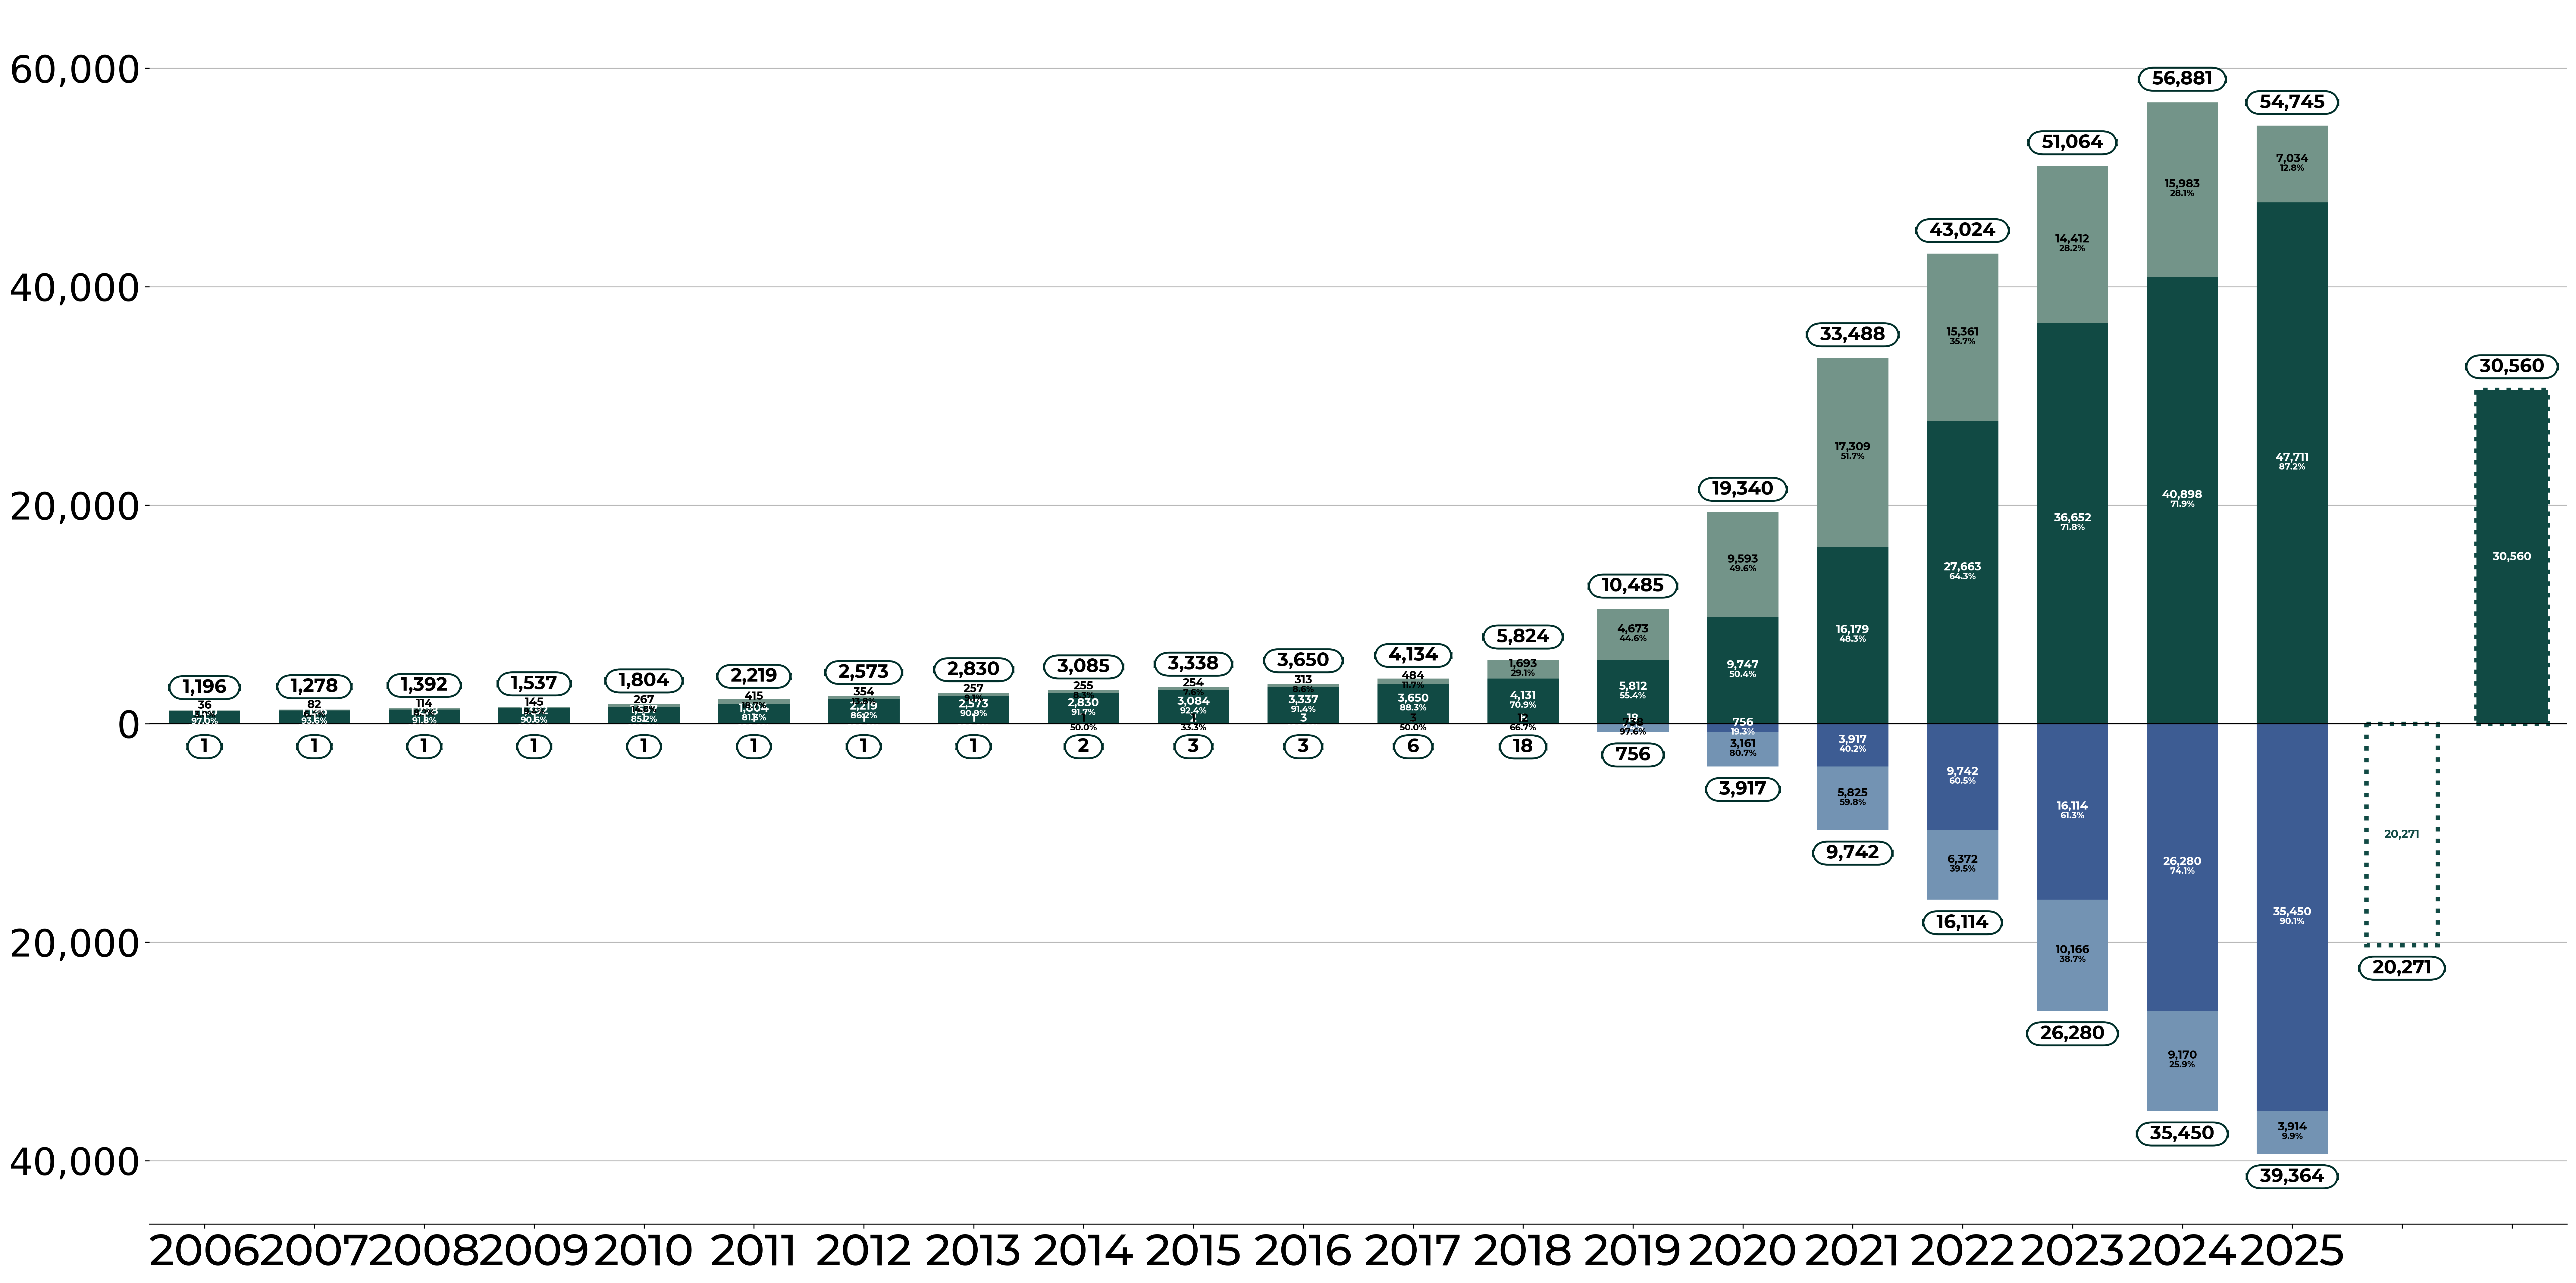

In [9]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[4]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[4]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-20271), [None, None, None, None, "20,271"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,30560), [None, None, None, None, "30,560"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']}) 
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.3,
       div_ejeY=False,
       )

Scour processed file "output/dataframe_6.svg" in 171 ms: 56730/94732 bytes new/orig -> 59.9%


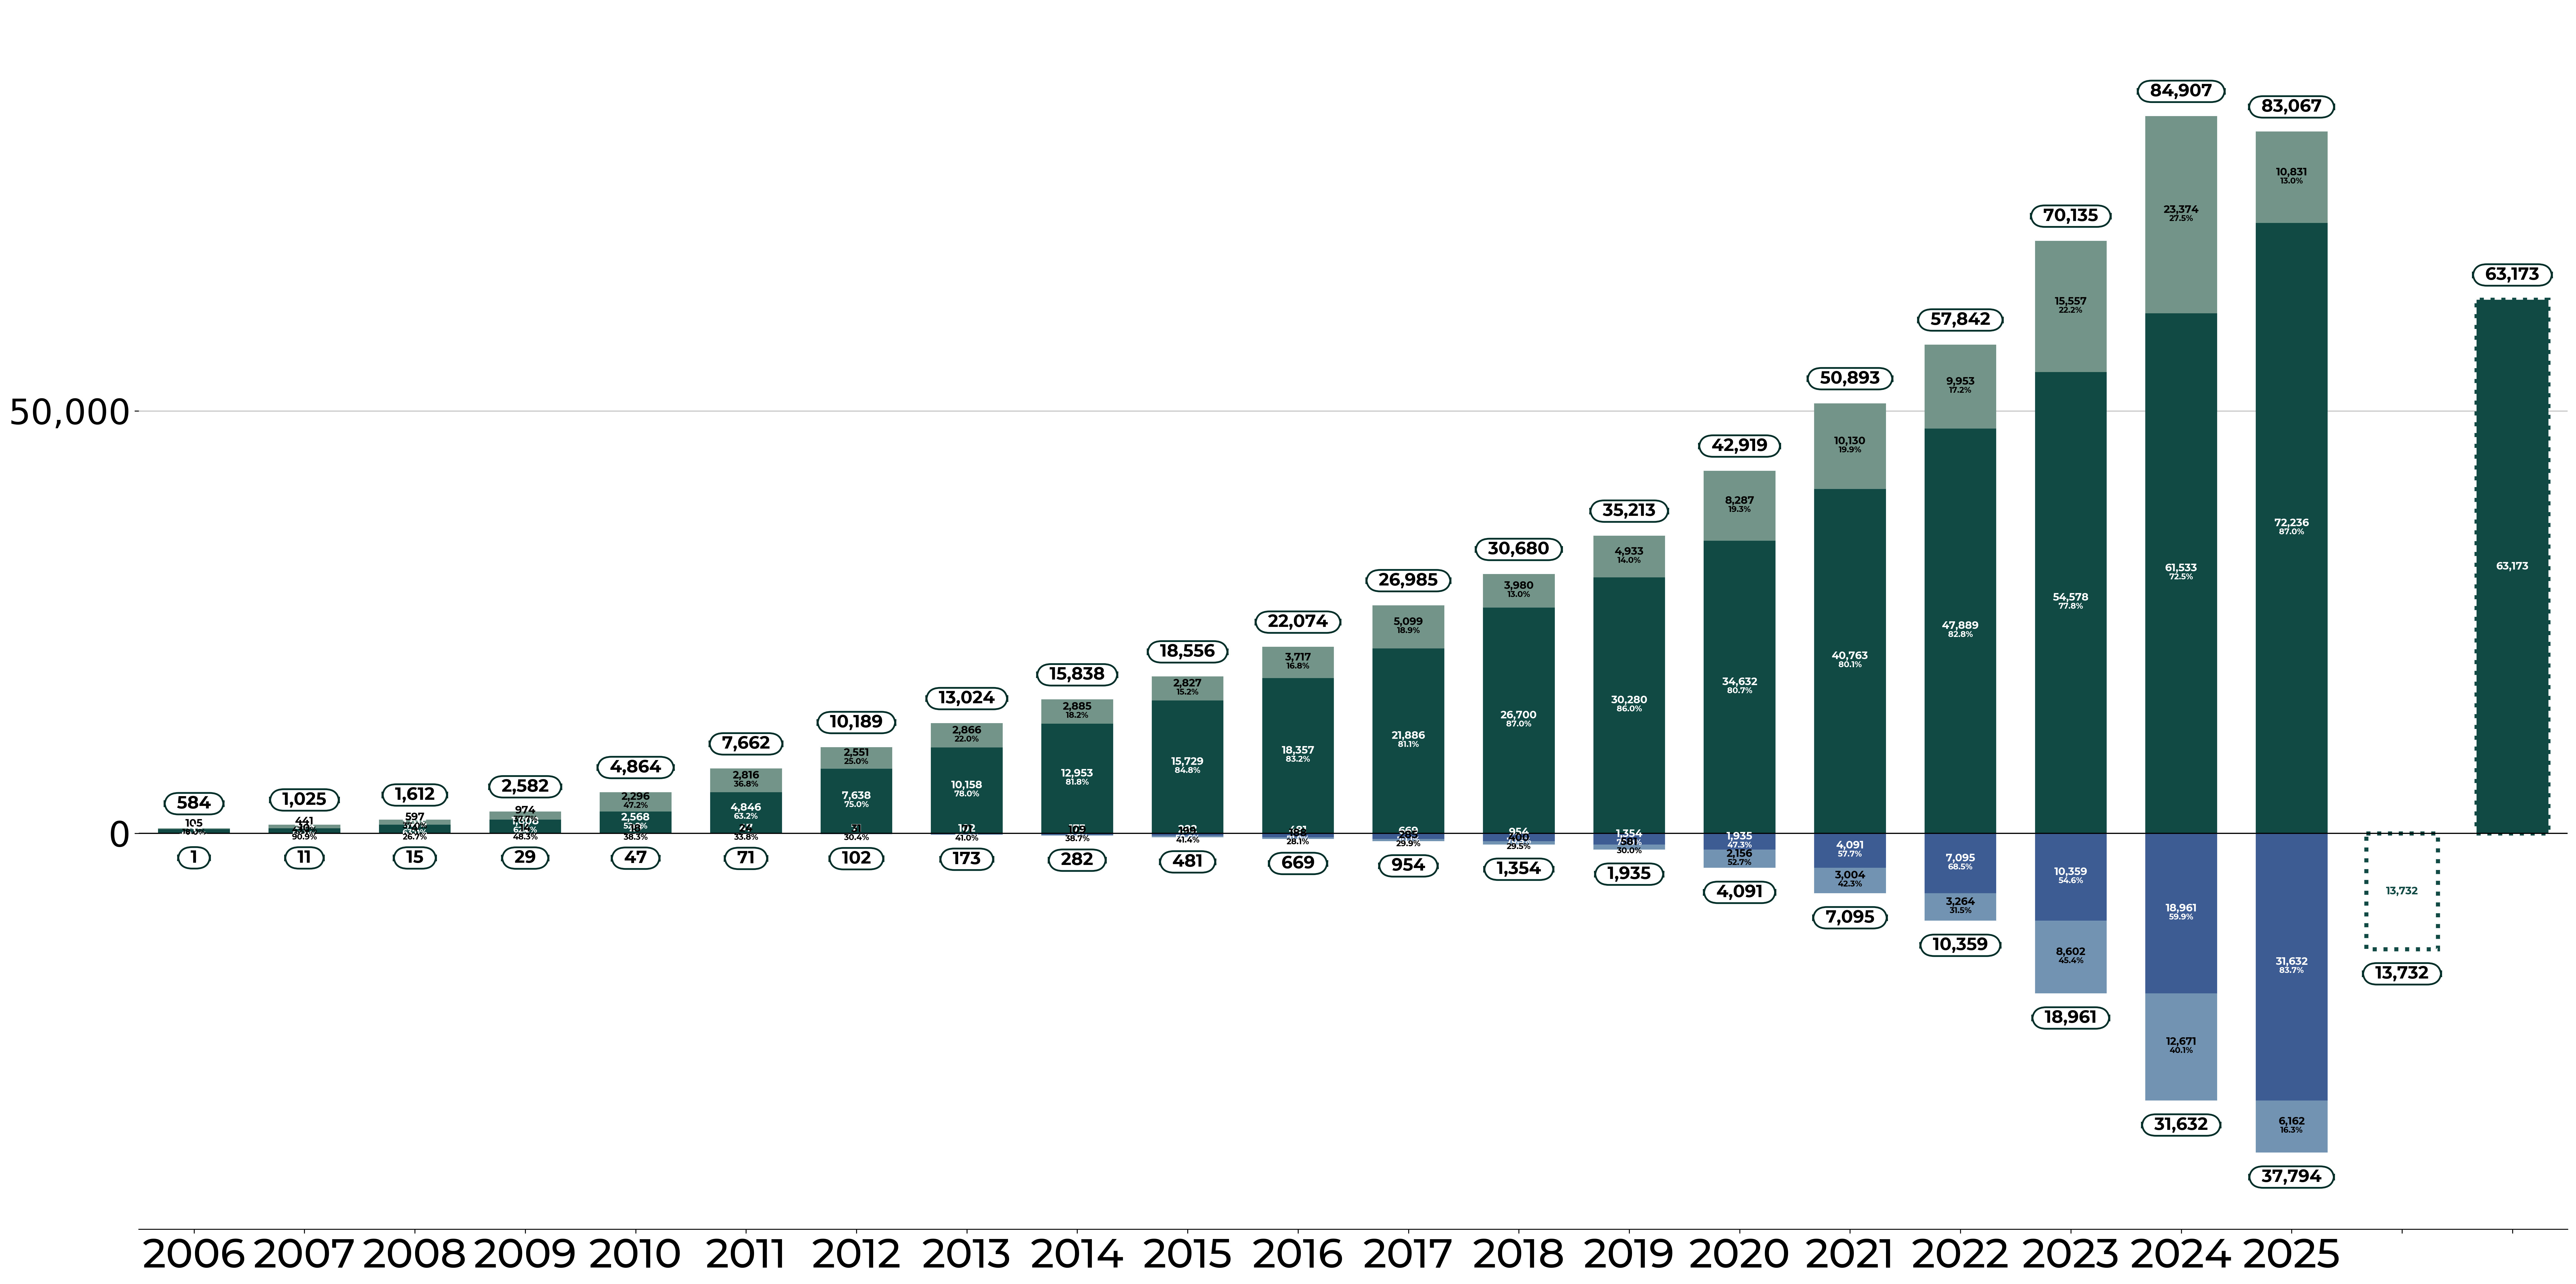

In [10]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[5]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[5]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-13732), [None, None, None, None, "13,732"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,63173), [None, None, None, None, "63,173"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.52,
       div_ejeY=50000,
       )

Scour processed file "output/dataframe_7.svg" in 186 ms: 59330/98394 bytes new/orig -> 60.3%


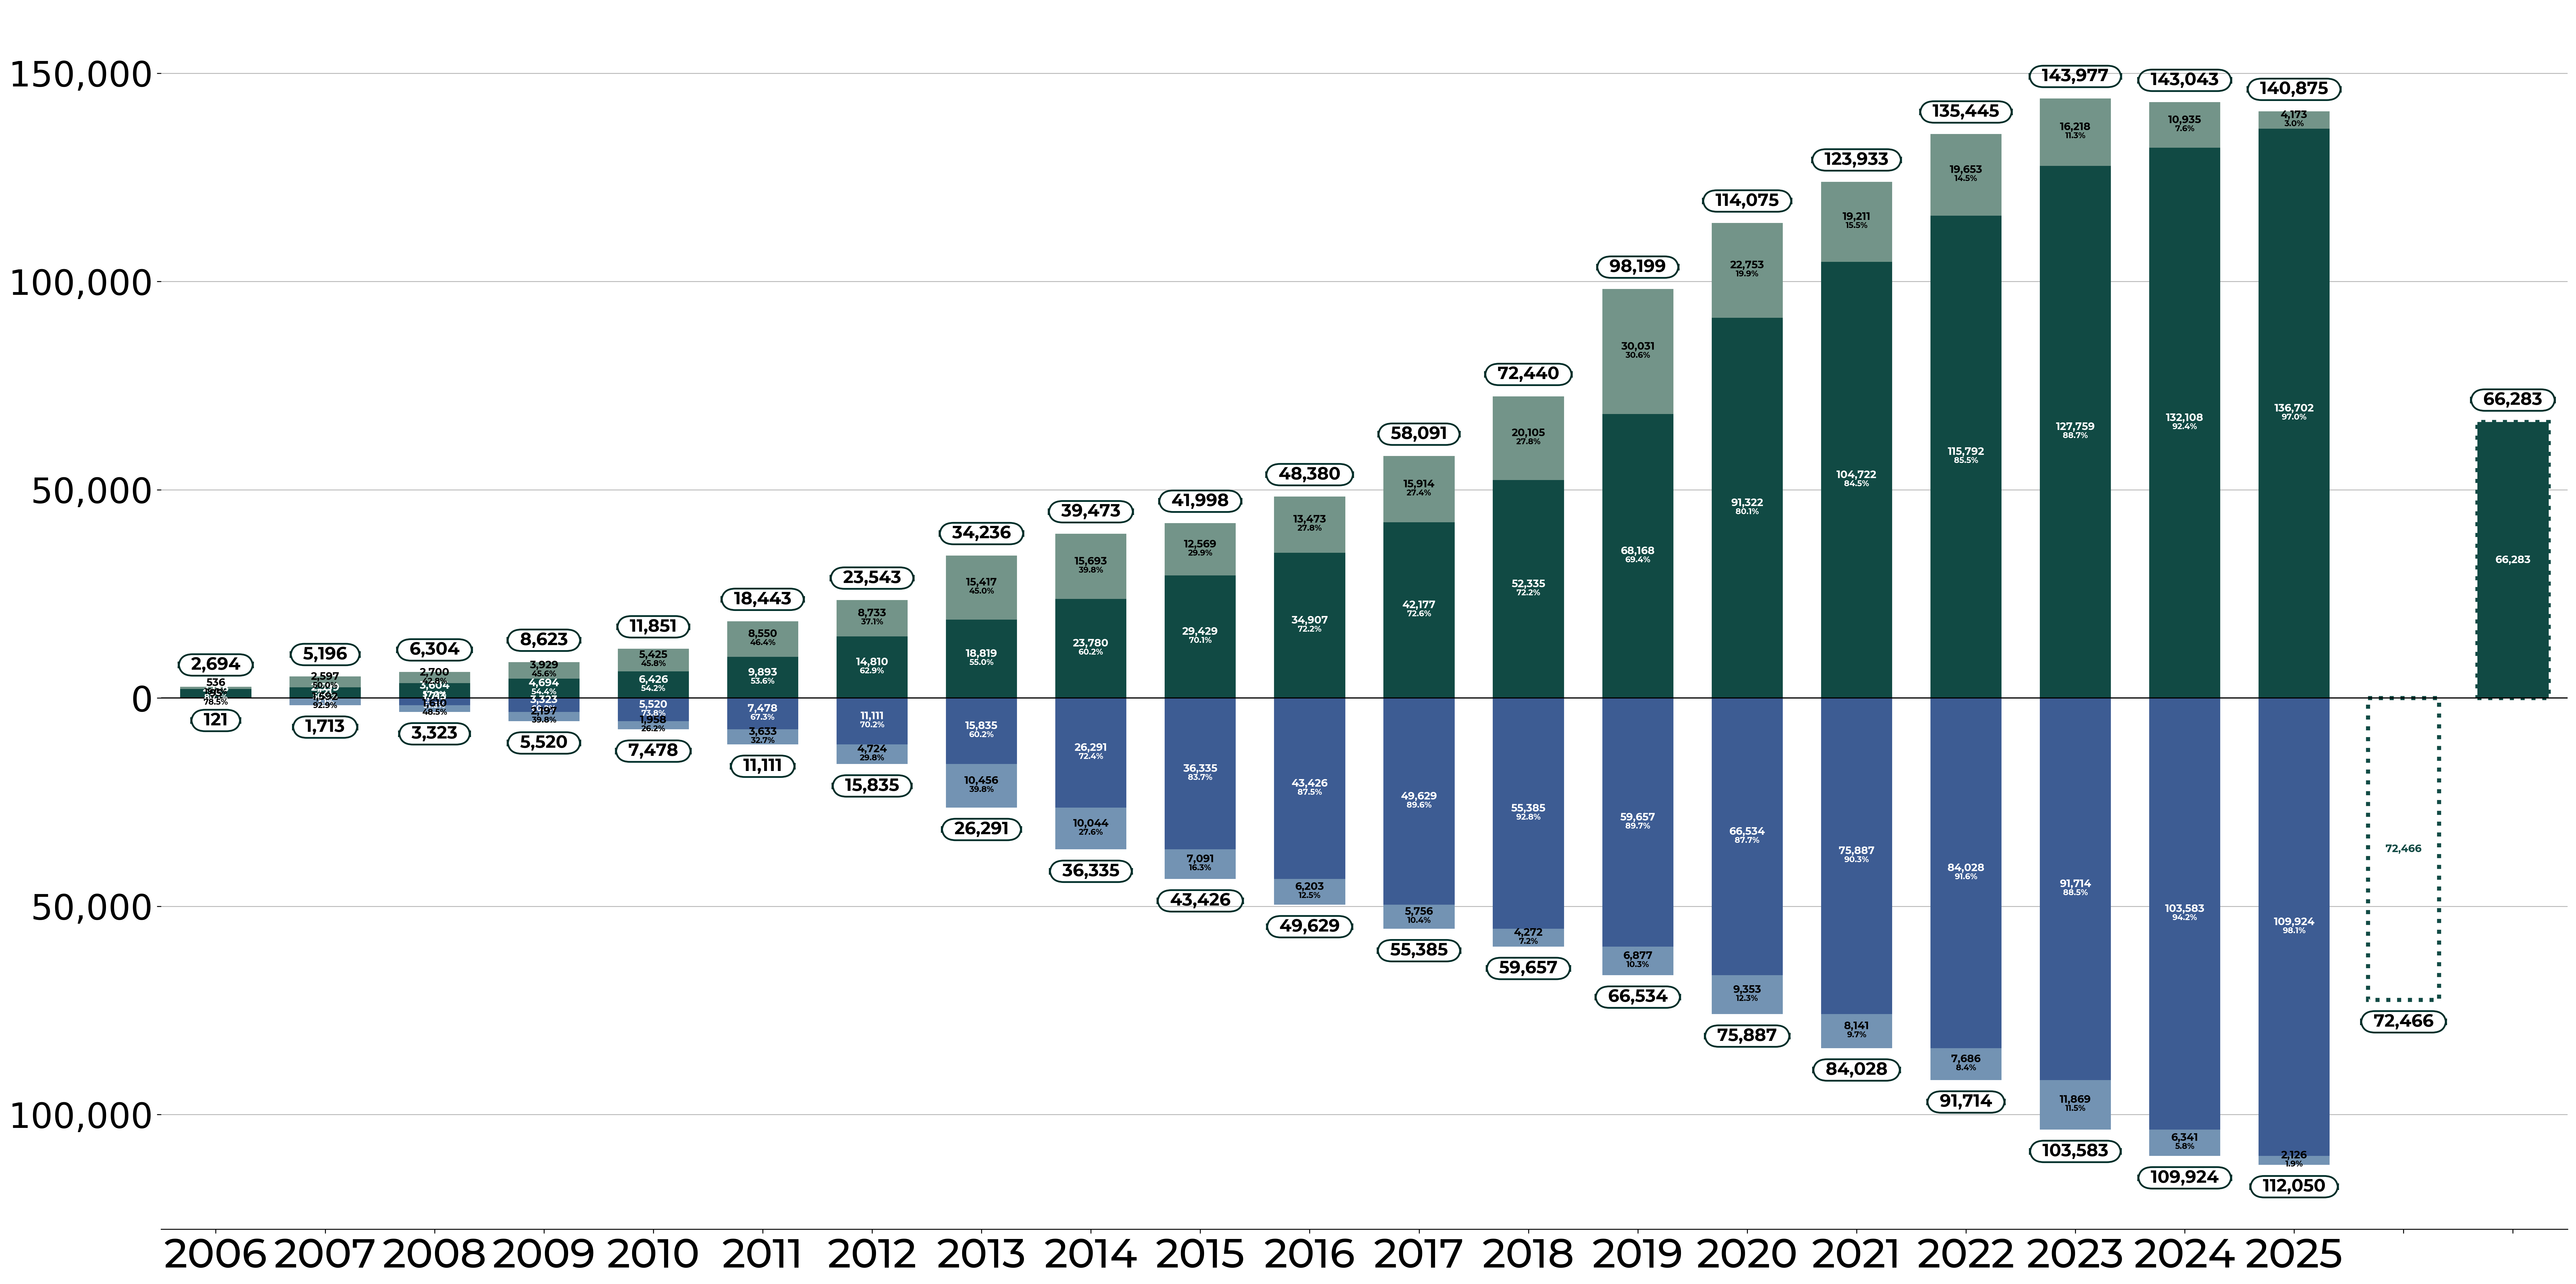

In [11]:
barras_verticales(dataframes_filtrados[list(dataframes_filtrados.keys())[6]], 
       nombre=f"dataframe_{list(dataframes_filtrados.keys())[6]}", 
       ancho_barra=0.65, 
       tipo_letra='Montserrat',
       tam_letra_valor_barra=9,
       tam_letra_porce_barra=7,
       tam_letra_valor_capsu=15,
       ordenar_por=False,
       orden='ascendente',
       valor_barra=True, 
       valor_capsu=True,
       porce_barra=True,
       porce_total=False,
       area_min=0,
       porce_abajo=True,
       leyenda=False,
       orientacion_etiqu_ejeX='horizontal',
       pos_leyenda='abajo',
       porce_diver=True,
       ejeY_positivo=True,
       paleta_colores=["#114a44", "#739489", "#3d5c93", "#7393b3", "#6B5B95",],
       agregar_datos=[(pd.Timestamp(2026, 1, 1), " ", (0,0,0,0,-72466), [None, None, None, None, "72,466"], {'colores_fondo': [None, None, None, None, 'none'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, '#114a44']}),
                      (pd.Timestamp(2027, 1, 1), " ", (0,0,0,0,66283), [None, None, None, None, "66,283"], {'colores_fondo': [None, None, None, None, '#114a44'], 'colores_borde': [None, None, None, None, '#114a44'], 'estilos_borde': [None, None, None, None, 'dotted'],'grosores_borde': [None, None, None, None, 3.5], 'colores_texto': [None, None, None, None, 'white']})
                      ],
       capsu_cero=False,
       ncol_leyenda=2,
       aumenta_sep_eje_x=-0.23,
       div_ejeY=50000,
       )